In [1]:
import os
import pathlib
import shutil
import subprocess
import math
from dataclasses import dataclass

import numpy as np

# Compatibility: plotly expects np.bool8 in some envs
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

try:
    import pandas as pd
except Exception as e:
    pd = None
    print('Note: pandas not available:', e)

import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (9, 4.5),
    'axes.grid': True,
})

ROOT = pathlib.Path.cwd().resolve()
print('CWD:', ROOT)
print('Scenario dir exists:', (ROOT / '..' / 'scenario').resolve().exists())

CWD: /home/abhay/Major_Project/vanet_task_offloading/examples
Scenario dir exists: True


In [2]:
# --- OMNeT++ environment setup (needed for opp_run / Veins) ---

def source_bash_env(script_path: str):
    cmd = f"bash -lc 'source {script_path} && env -0'"
    out = subprocess.check_output(cmd, shell=True)
    for chunk in out.split(b'\x00'):
        if not chunk:
            continue
        k, _, v = chunk.partition(b'=')
        if k:
            os.environ[k.decode()] = v.decode()

# Prefer env var override, else fall back to the path used in your other notebooks
OMNETPP_SETENV = os.environ.get('OMNETPP_SETENV', '/home/abhay/omnetpp-5.7.1/setenv')

if os.path.exists(OMNETPP_SETENV):
    source_bash_env(OMNETPP_SETENV)
    print('Sourced:', OMNETPP_SETENV)
else:
    print('Warning: OMNeT++ setenv not found at:', OMNETPP_SETENV)

print('opp_run:', shutil.which('opp_run'))
print('sumo:', shutil.which('sumo'))

Sourced: /home/abhay/omnetpp-5.7.1/setenv
opp_run: /home/abhay/omnetpp-5.7.1/bin/opp_run
sumo: /usr/bin/sumo


In [3]:
import gym
import veins_gym

def ensure_veins_env_registered():
    # Register only once (avoids errors when re-running cells).
    try:
        gym.spec('veins-straight-v1')
        return
    except Exception:
        pass

    gym.register(
        id='veins-straight-v1',
        entry_point='veins_gym:VeinsEnv',
        kwargs={
            'scenario_dir': '../scenario',
            'timeout': 7.0,
            'print_veins_stdout': False,
            'user_interface': 'Cmdenv',
            'config': 'StraightRoad',
        },
    )

ensure_veins_env_registered()
print('Registered/available:', 'veins-straight-v1')

Registered/available: veins-straight-v1


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [4]:
# --- Evaluation helpers ---

TASK_MB_THRESHOLD = 1.0

def _reset_obs_only(reset_out):
    # Gym vs Gymnasium compatibility
    if isinstance(reset_out, tuple) and len(reset_out) >= 1:
        return reset_out[0]
    return reset_out

def _step_unpack(step_out):
    # Returns: obs, reward, done, info
    if isinstance(step_out, tuple) and len(step_out) == 5:
        obs, reward, terminated, truncated, info = step_out
        done = bool(terminated) or bool(truncated)
        return obs, float(reward), done, info
    obs, reward, done, info = step_out
    return obs, float(reward), bool(done), info

def _safe_int_seed(x: int) -> int:
    return int(int(x) % (2**31 - 1))

@dataclass
class EpisodeResult:
    agent: str
    seed: int
    episode_steps: int
    n_task_steps: int
    mean_task_reward: float
    sum_task_reward: float

def run_episode(agent_name: str, policy_fn, seed: int, env_builder, track_actions: bool = True):
    env = env_builder()
    obs = _reset_obs_only(env.reset(seed=_safe_int_seed(seed)))

    task_rewards = []
    task_actions = []
    task_sizes = []

    steps = 0
    done = False
    while not done:
        action = policy_fn(obs, env)
        prev_obs = obs
        obs, reward, done, info = _step_unpack(env.step(action))

        # Task-focused logging
        try:
            task_mb = float(np.asarray(prev_obs).ravel()[4])
        except Exception:
            task_mb = float('nan')

        if (not math.isnan(task_mb)) and task_mb >= float(TASK_MB_THRESHOLD):
            task_rewards.append(float(reward))
            task_sizes.append(task_mb)
            if track_actions:
                try:
                    if isinstance(action, (list, tuple, np.ndarray)):
                        task_actions.append(np.asarray(action).ravel().tolist())
                    else:
                        task_actions.append(int(action))
                except Exception:
                    task_actions.append(action)

        steps += 1

    try:
        env.close()
    except Exception:
        pass

    mean_task = float(np.mean(task_rewards)) if task_rewards else 0.0
    sum_task = float(np.sum(task_rewards)) if task_rewards else 0.0

    ep = EpisodeResult(
        agent=agent_name,
        seed=int(seed),
        episode_steps=int(steps),
        n_task_steps=int(len(task_rewards)),
        mean_task_reward=mean_task,
        sum_task_reward=sum_task,
    )
    return ep, {
        'task_rewards': task_rewards,
        'task_actions': task_actions,
        'task_sizes': task_sizes,
    }

def ci95_mean(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return 0.0, 0.0, 0.0
    m = float(values.mean())
    if values.size < 2:
        return m, m, m
    s = float(values.std(ddof=1))
    half = 1.96 * s / math.sqrt(values.size)
    return m, m - half, m + half

In [5]:
# --- Agents (baselines + RL) ---

from nearest_free_rsu_agent import pick_action as greedy_pick_action

def build_env_base():
    ensure_veins_env_registered()
    return gym.make('veins-straight-v1')

def policy_local(obs, env):
    return 0

def policy_random(obs, env):
    return env.action_space.sample()

def policy_greedy(obs, env):
    return int(greedy_pick_action(obs))

# RL (PPO discrete)
PPO_MODEL_PATH = 'models/ppo_20k_v3.zip'  # change to your saved model
ppo_model = None

try:
    from stable_baselines3 import PPO
    if os.path.exists(PPO_MODEL_PATH):
        ppo_model = PPO.load(PPO_MODEL_PATH)
        print('Loaded PPO model:', PPO_MODEL_PATH)
    else:
        print('PPO model not found (skipping RL agent):', PPO_MODEL_PATH)
except Exception as e:
    print('stable-baselines3 not available (skipping RL agent):', e)

def policy_rl_ppo(obs, env):
    # deterministic for evaluation
    action, _ = ppo_model.predict(obs, deterministic=True)
    return int(action)

# RL+PSO hybrid (PPO outputs PSO hyperparams)
PSO_MODEL_PATH = 'models/pso_final.zip'  # change if needed
pso_model = None

try:
    from train_rl_pso import RLPSOWrapper
    if 'PPO' in globals() and os.path.exists(PSO_MODEL_PATH):
        pso_model = PPO.load(PSO_MODEL_PATH)
        print('Loaded RL+PSO PPO model:', PSO_MODEL_PATH)
    else:
        if not os.path.exists(PSO_MODEL_PATH):
            print('RL+PSO model not found (skipping):', PSO_MODEL_PATH)
except Exception as e:
    print('RLPSOWrapper not available (skipping RL+PSO):', e)

#####
def policy_rl_pso(obs, env):
    # deterministic for evaluation
    action, _ = pso_model.predict(obs, deterministic=True)
    return int(action)

def build_env_rl_pso():
    env = build_env_base()
    return RLPSOWrapper(env, num_actions=4)

Loaded PPO model: models/ppo_20k_v3.zip
Loaded RL+PSO PPO model: models/pso_final.zip


/home/abhay/anaconda3/envs/mp/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [6]:
# --- Run evaluation ---

TRIALS = 100
BASE_SEED = 12345

rng = np.random.default_rng(BASE_SEED)
seeds = rng.integers(0, 2**31 - 1, size=TRIALS, dtype=np.int64).tolist()


agents = [
    ('Local', policy_local, build_env_base),
    ('Random', policy_random, build_env_base),
    ('Greedy', policy_greedy, build_env_base),
]

if ppo_model is not None:
    agents.append(('RL (PPO)', policy_rl_ppo, build_env_base))

if pso_model is not None:
    agents.append(('RL+PSO (PPO)', policy_rl_pso, build_env_base))

episode_rows = []
step_rows = []

for agent_name, policy_fn, env_builder in agents:
    for ep_i, seed in enumerate(seeds, start=1):
        ep_res, details = run_episode(agent_name, policy_fn, int(seed), env_builder, track_actions=True)
        episode_rows.append({
            'agent': ep_res.agent,
            'episode': ep_i,
            'seed': ep_res.seed,
            'episode_steps': ep_res.episode_steps,
            'n_task_steps': ep_res.n_task_steps,
            'mean_task_reward': ep_res.mean_task_reward,
            'sum_task_reward': ep_res.sum_task_reward,
        })

        # Store per-task-step rows for distributions/plots
        for j, (r, a, tmb) in enumerate(zip(details['task_rewards'], details['task_actions'], details['task_sizes'])):
            step_rows.append({
                'agent': agent_name,
                'episode': ep_i,
                'task_step_index': j,
                'task_mb': float(tmb),
                'reward': float(r),
                'action': a,
            })

        # print(f"{agent_name:12s} ep {ep_i:02d}/{TRIALS}: mean_task_reward={ep_res.mean_task_reward:.4f} (task_steps={ep_res.n_task_steps})")

if pd is None:
    print('pandas missing: plots will still work, but tables will be basic lists/dicts.')

df_ep = pd.DataFrame(episode_rows) if pd is not None else episode_rows
df_steps = pd.DataFrame(step_rows) if pd is not None else step_rows

/home/abhay/anaconda3/envs/mp/lib/python3.13/site-packages/gym/utils/passive_env_checker.py:181: UserWarning: WARN: The default seed argument in `Env.reset` should be `None`, otherwise the environment will by default always be deterministic. Actual default: seed='NO SEED GIVEN'
  logger.warn(
/home/abhay/anaconda3/envs/mp/lib/python3.13/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'numpy.ndarray'>`
  logger.warn(
/home/abhay/anaconda3/envs/mp/lib/python3.13/site-packages/gym/utils/passive_env_checker.py:219: DeprecationWarning: WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to rewrite the environment with new step API. 
  logger.deprecation(


In [7]:
# --- Summary table (mean ± 95% CI across episodes) ---

if pd is None:
    # Minimal summary without pandas
    by_agent = {}
    for row in episode_rows:
        by_agent.setdefault(row['agent'], []).append(row['mean_task_reward'])
    summary = []
    for agent, vals in by_agent.items():
        m, lo, hi = ci95_mean(vals)
        summary.append({'agent': agent, 'mean': m, 'ci_low': lo, 'ci_high': hi, 'n': len(vals)})
    summary
else:
    grp = df_ep.groupby('agent')['mean_task_reward']
    summary = grp.agg(['count', 'mean', 'std']).reset_index()
    # 95% CI (normal approx)
    summary['ci_half'] = 1.96 * summary['std'] / np.sqrt(summary['count'].clip(lower=1))
    summary['ci_low'] = summary['mean'] - summary['ci_half']
    summary['ci_high'] = summary['mean'] + summary['ci_half']
    summary = summary.drop(columns=['std', 'ci_half']).sort_values('mean', ascending=False)
    summary

In [8]:
print(summary)

          agent  count       mean     ci_low    ci_high
2      RL (PPO)    100  13.265900  12.798086  13.733714
3  RL+PSO (PPO)    100  12.942732  12.456755  13.428709
0        Greedy    100  12.170740  11.686594  12.654885
1         Local    100   9.356989   9.069101   9.644877
4        Random    100   7.785767   7.448759   8.122775


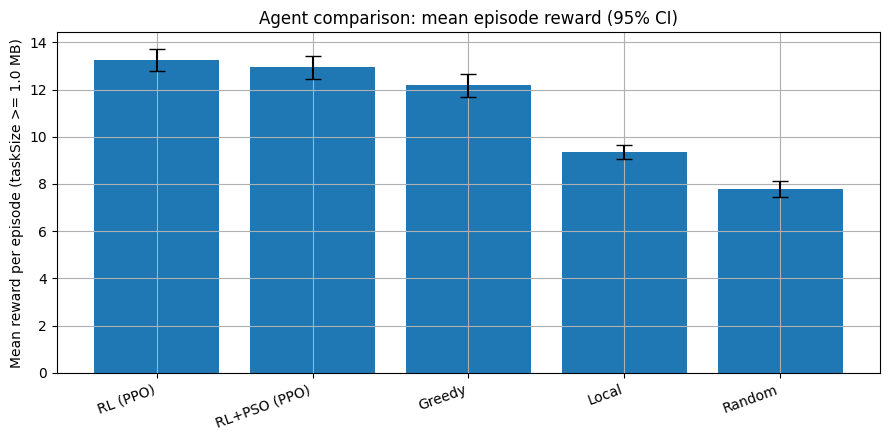

In [9]:
# --- Visualization 1: Bar chart of mean episode reward (task steps only) + 95% CI ---

if pd is not None:
    plot_df = summary.copy()
    agents_order = plot_df['agent'].tolist()
    means = plot_df['mean'].to_numpy()
    yerr = np.vstack([means - plot_df['ci_low'].to_numpy(), plot_df['ci_high'].to_numpy() - means])

    plt.figure()
    plt.bar(agents_order, means, yerr=yerr, capsize=6)
    plt.ylabel(f'Mean reward per episode (taskSize >= {TASK_MB_THRESHOLD} MB)')
    plt.title('Agent comparison: mean episode reward (95% CI)')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Install pandas to enable this plot: pip install pandas')

/tmp/ipykernel_7049/1666067256.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=agents_order, showmeans=True)


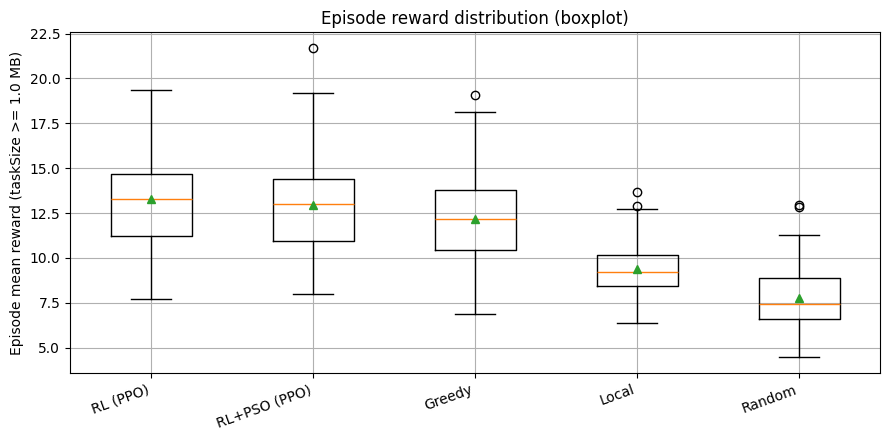

In [10]:
# --- Visualization 2: Boxplot of episode mean rewards ---

if pd is not None:
    plt.figure()
    agents_order = summary['agent'].tolist()
    data = [df_ep[df_ep['agent'] == a]['mean_task_reward'].to_numpy() for a in agents_order]
    plt.boxplot(data, labels=agents_order, showmeans=True)
    plt.ylabel(f'Episode mean reward (taskSize >= {TASK_MB_THRESHOLD} MB)')
    plt.title('Episode reward distribution (boxplot)')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Install pandas to enable this plot: pip install pandas')

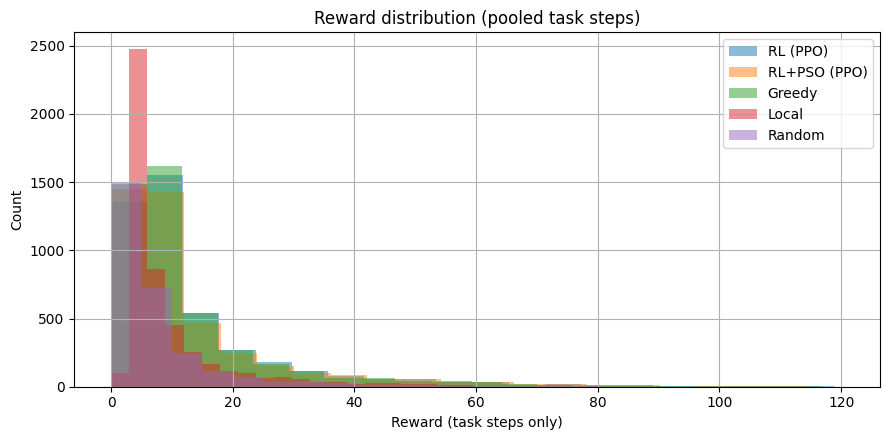

In [11]:
# --- Visualization 3: Reward histogram on task steps (all episodes pooled) ---

if pd is not None and len(df_steps) > 0:
    plt.figure()
    for agent in summary['agent'].tolist():
        vals = df_steps[df_steps['agent'] == agent]['reward'].to_numpy()
        if vals.size == 0:
            continue
        plt.hist(vals, bins=20, alpha=0.5, label=agent)
    plt.xlabel('Reward (task steps only)')
    plt.ylabel('Count')
    plt.title('Reward distribution (pooled task steps)')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No task-step data collected (or pandas missing).')

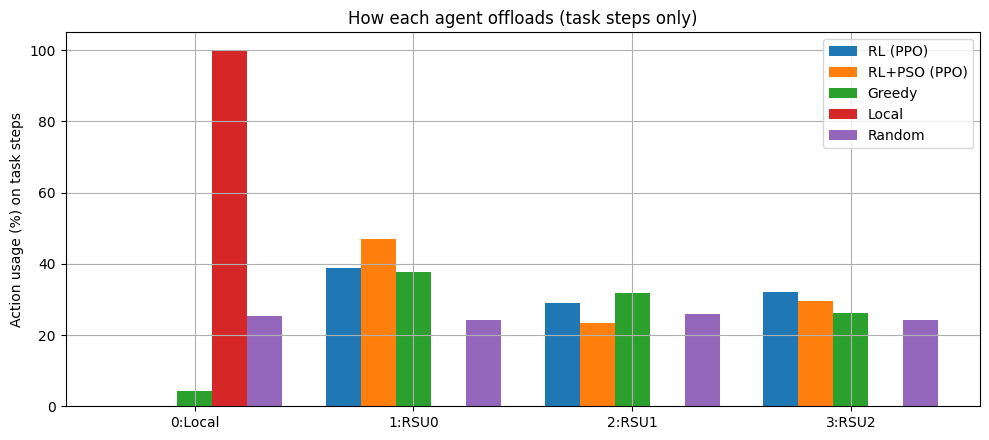

In [12]:
# --- Visualization 4: Action usage (discrete agents only) ---
# Actions: 0=Local, 1=RSU0, 2=RSU1, 3=RSU2

if pd is not None and len(df_steps) > 0:
    # Keep only rows where action is an int (skip RL+PSO continuous params)
    tmp = df_steps.copy()
    tmp['action_int'] = pd.to_numeric(tmp['action'], errors='coerce')
    tmp = tmp.dropna(subset=['action_int'])
    tmp['action_int'] = tmp['action_int'].astype(int)

    if len(tmp) == 0:
        print('No discrete actions logged (maybe only continuous agents ran).')
    else:
        action_counts = (
            tmp.groupby(['agent', 'action_int']).size().reset_index(name='count')
        )
        # Normalize to percentages per agent
        totals = action_counts.groupby('agent')['count'].transform('sum')
        action_counts['pct'] = 100.0 * action_counts['count'] / totals

        agents_order = summary['agent'].tolist()
        actions = [0, 1, 2, 3]
        x = np.arange(len(actions))
        width = 0.8 / max(1, len(agents_order))

        plt.figure(figsize=(10, 4.5))
        for i, agent in enumerate(agents_order):
            vals = []
            for a in actions:
                row = action_counts[(action_counts['agent'] == agent) & (action_counts['action_int'] == a)]
                vals.append(float(row['pct'].iloc[0]) if len(row) else 0.0)
            plt.bar(x + i * width, vals, width=width, label=agent)

        plt.xticks(x + (len(agents_order) - 1) * width / 2, ['0:Local', '1:RSU0', '2:RSU1', '3:RSU2'])
        plt.ylabel('Action usage (%) on task steps')
        plt.title('How each agent offloads (task steps only)')
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print('Install pandas to enable this plot: pip install pandas')

/tmp/ipykernel_7049/2833025579.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = tmp.groupby(['agent', 'task_bin'])['reward'].mean().reset_index()


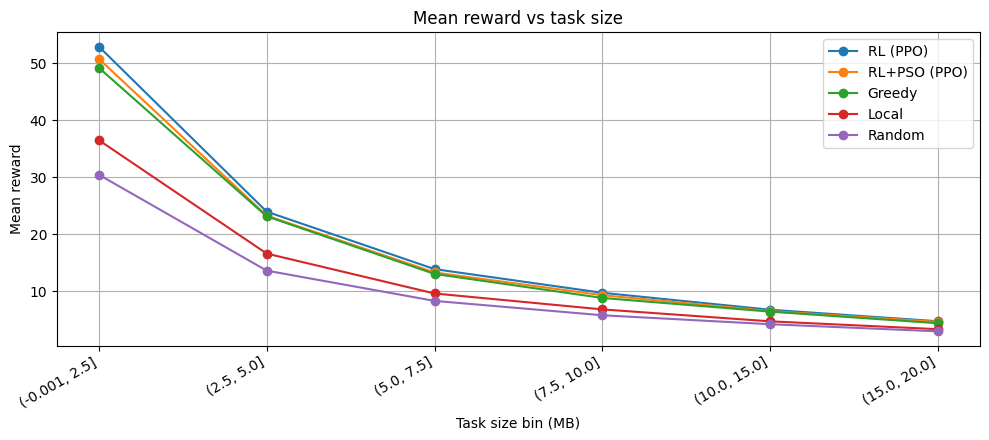

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

tmp = df_steps.copy()
tmp['task_bin'] = pd.cut(tmp['task_mb'], bins=[0, 2.5, 5, 7.5, 10, 15, 20, float('inf')], include_lowest=True)
binned = tmp.groupby(['agent', 'task_bin'])['reward'].mean().reset_index()

plt.figure(figsize=(10, 4.5))
for agent in summary['agent'].tolist():
    sub = binned[binned['agent'] == agent]
    plt.plot(sub['task_bin'].astype(str), sub['reward'], marker='o', label=agent)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Mean reward')
plt.xlabel('Task size bin (MB)')
plt.title('Mean reward vs task size')
plt.legend()
plt.tight_layout()
plt.show()

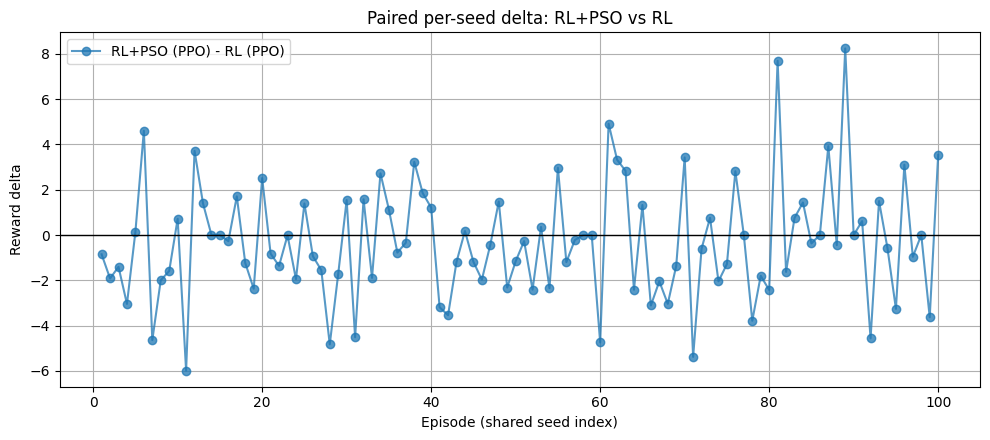

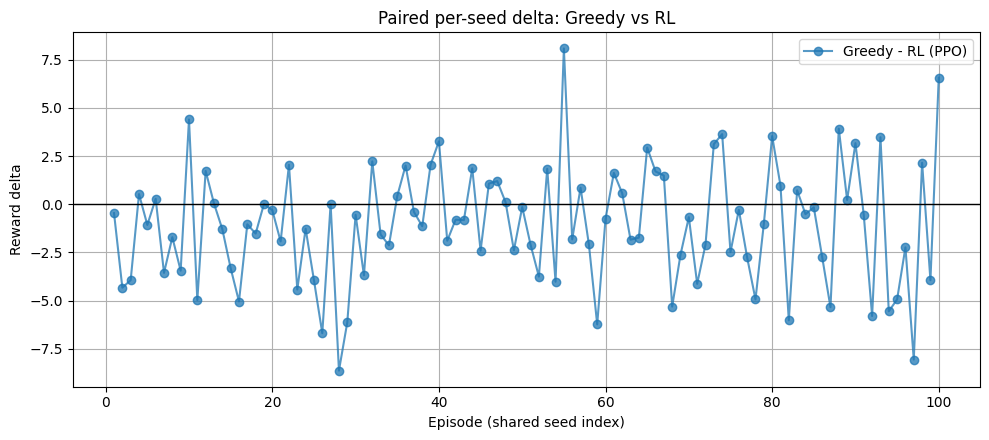

In [30]:
import matplotlib.pyplot as plt

pivot = df_ep.pivot(index='episode', columns='agent', values='mean_task_reward')
rl_name = 'RL (PPO)'

pairs = [
    ('RL+PSO (PPO)', 'Paired per-seed delta: RL+PSO vs RL'),
    ('Greedy', 'Paired per-seed delta: Greedy vs RL'),
]

for other, title in pairs:
    if rl_name not in pivot.columns or other not in pivot.columns:
        print(f"Skipping {other}: missing in df_ep")
        continue

    d = pivot[other] - pivot[rl_name]

    plt.figure(figsize=(10, 4.5))
    plt.plot(d.index, d.values, marker='o', linestyle='-', alpha=0.75, label=f'{other} - {rl_name}')
    plt.axhline(0, color='black', linewidth=1)
    plt.xlabel('Episode (shared seed index)')
    plt.ylabel('Reward delta')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()